# Energy Asset Risk & Cost Model

## Overview  
This project presents a **simulation-based machine learning workflow** designed to model **energy asset risk, claim probability, and financial exposure**.

It demonstrates how publicly available data can be transformed into **actionable risk insights** using a combination of:
- Feature engineering  
- Machine learning models  
- Financial risk estimation  
- Dashboard-ready outputs  

The workflow is structured to reflect how a real-world **energy or insurance analytics solution** would be developed.

---

## Business Context  
Energy infrastructure assets (e.g., power plants) carry varying levels of operational and financial risk.

In a real-world setting, organisations such as:
- Insurance providers  
- Energy companies  
- Risk consultants  

need to:

- Identify high-risk assets  
- Estimate the likelihood of adverse events  
- Quantify potential financial exposure  
- Prioritise monitoring and mitigation strategies  

This project simulates that decision-making process.

---

## Dataset  
- Source: Kaggle – Global Power Plant Database  
- Includes:
  - Asset location (country, latitude, longitude)  
  - Fuel type  
  - Capacity (MW)  
  - Generation estimates  
  - Commissioning year  

---

## Modelling Approach  

### Feature Engineering  
Domain-informed features were created to simulate real risk drivers:

- Asset age  
- Capacity × age interaction  
- Capacity per age (operational stress proxy)  
- Fuel-based risk weighting  
- High-capacity and legacy asset flags  

---

### Target Construction (Simulation)  
The following targets are **synthetically engineered**:

- `risk_score` → continuous risk index (0–100)  
- `claim_occurred` → binary event indicator  
- `expected_loss_gbp` → simulated financial exposure  

These are designed to replicate a realistic **risk modelling scenario** using non-proprietary data.

---

### Machine Learning Models  

#### Regression (Risk Scoring)
- Random Forest Regressor  
- Gradient Boosting Regressor  

#### Classification (Event Probability)
- Random Forest Classifier (with class balancing)  
- Gradient Boosting Classifier (with sample weighting)  

Models are evaluated using:
- Holdout validation  
- Cross-validation (k-fold)  

---

## Model Outputs  

The pipeline produces:

- Predicted risk score  
- Predicted claim probability  
- Binary event prediction  
- Screening flag for risk prioritisation  
- Predicted expected financial loss  

These outputs are structured for **downstream analytics and dashboarding**.

---

## Key Deliverables  

### Main Dataset  
`energy_asset_risk_predictions.csv`  
Contains asset-level predictions and financial metrics.

### Summary Outputs  
- Fuel-level aggregation  
- Country-level aggregation  

### Feature Importance  
- Regression and classification drivers  
- Combined dataset for visual analysis  

---

## Important Disclaimer  

This project is a **simulation-based portfolio exercise**.

- All target variables are **synthetically generated**  
- No real insurance claims or proprietary data is used  
- Financial assumptions (e.g. loss rates) are **illustrative proxies**  

This work is intended to demonstrate:
> A complete energy asset risk modelling workflow  

and should not be interpreted as:
> A production-ready actuarial or insurance pricing model  

---

## Tools & Technologies  

- Python (Pandas, NumPy, Scikit-learn)  
- Google Colab  
- Matplotlib (EDA)  
- Power BI (dashboard integration)  

---

## Skills Demonstrated  

- Data cleaning and preprocessing  
- Feature engineering  
- Regression and classification modelling  
- Model evaluation and cross-validation  
- Handling class imbalance  
- Business-oriented metric design  
- End-to-end ML pipeline development  
- Data storytelling and reporting  

---

## Next Steps  

The outputs from this notebook are designed for integration into a **Power BI dashboard**, enabling:

- Risk segmentation  
- Geographic analysis  
- Financial exposure tracking  
- Interactive decision support  

---

## Author  

Richard McInerney  
Data Analyst | Machine Learning | Power BI  

---

## Project Summary  

This project demonstrates how machine learning can be applied to:
- Assess asset-level risk  
- Estimate event probability  
- Quantify financial exposure  

within a structured, end-to-end workflow aligned to **energy and insurance analytics use cases**.

In [1]:
# Cell 2 Import Kaggle Dataset

import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("eshaan90/global-power-plant-database")

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

# Assuming the main CSV file is the first one found or specifically named
# For this dataset, the file is 'global_power_plant_database.csv'
dataset_file_path = os.path.join(path, csv_files[0]) # Or specify the exact filename if known

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_file_path)

print("Path to dataset files:", path)
print("Dataset loaded successfully into DataFrame 'df'.")

100%|██████████| 2.51M/2.51M [00:00<00:00, 41.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/eshaan90/global-power-plant-database/versions/1
Dataset loaded successfully into DataFrame 'df'.


In [2]:
# Cell 3 Import Pandas - shape/clean data

import pandas as pd
import numpy as np

# Set display options for better viewing of wide dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Create working copy
power_df = df.copy()

# Standardise column names
power_df.columns = (
    power_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
)

# Remove duplicate rows if any
power_df = power_df.drop_duplicates()

# Basic inspection
print("Dataset shape:", power_df.shape)
print("\nColumns:")
print(list(power_df.columns))

print("\nData types:")
print(power_df.dtypes)

print("\nMissing values:")
print(power_df.isnull().sum().sort_values(ascending=False))

print("\nFirst 5 rows:")
display(power_df.head())

print("\nSummary statistics:")
display(power_df.describe(include="all").T)


Dataset shape: (28664, 22)

Columns:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'fuel1', 'fuel2', 'fuel3', 'fuel4', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'estimated_generation_gwh']

Data types:
country                      object
country_long                 object
name                         object
gppd_idnr                    object
capacity_mw                 float64
latitude                    float64
longitude                   float64
fuel1                        object
fuel2                        object
fuel3                        object
fuel4                        object
commissioning_year          float64
owner                        object
source                       object
url                          object
geolocation_source           object
year_of_capacity_data       float6

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,commissioning_year,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,28664,164,USA,8119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_long,28664,164,United States of America,8119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,28644,28261,LUJAN DE CUYO,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gppd_idnr,28664,28664,GEODB0003803,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capacity_mw,28664.0,NaN,NaN,NaN,186.0976,523.027253,1.0,4.79585,18.64,99.2,22500.0
latitude,28664.0,NaN,NaN,NaN,68.817502,3610.172087,-77.847,28.010225,39.95,46.980275,415750.0
longitude,28664.0,NaN,NaN,NaN,99.256208,10927.81083,-179.9777,-79.057475,-3.9284,21.007025,1075744.39
fuel1,28661,15,Hydro,7034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel2,1705,11,Gas,1010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel3,296,11,Gas,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Cell 4 - Select core fields and create first-pass feature set

# Keep only the most useful columns for modelling if they exist
preferred_columns = [
    "country",
    "country_long",
    "name",
    "gppd_idnr",
    "capacity_mw",
    "latitude",
    "longitude",
    "fuel1", # Changed from primary_fuel
    "fuel2", # Changed from other_fuel1
    "fuel3", # Changed from other_fuel2
    "fuel4", # Changed from other_fuel3
    "commissioning_year",
    "owner",
    "source",
    "generation_gwh_2013", # Changed from estimated_generation_gwh_2013
    "generation_gwh_2014", # Changed from estimated_generation_gwh_2014
    "generation_gwh_2015", # Changed from estimated_generation_gwh_2015
    "generation_gwh_2016", # Changed from estimated_generation_gwh_2016
    "estimated_generation_gwh" # Added this column that exists in power_df
]

available_columns = [col for col in preferred_columns if col in power_df.columns]
model_df = power_df[available_columns].copy()

# Rename 'fuel1' to 'primary_fuel' for consistency
if "fuel1" in model_df.columns:
    model_df = model_df.rename(columns={"fuel1": "primary_fuel"})

# Create asset age feature if commissioning year exists
current_year = pd.Timestamp.now().year
if "commissioning_year" in model_df.columns:
    model_df["commissioning_year"] = pd.to_numeric(model_df["commissioning_year"], errors="coerce")
    model_df["asset_age"] = current_year - model_df["commissioning_year"]
    model_df.loc[model_df["asset_age"] < 0, "asset_age"] = np.nan
else:
    model_df["asset_age"] = np.nan

# Create average estimated generation if yearly generation columns exist
generation_cols_candidates = [
    "generation_gwh_2013",
    "generation_gwh_2014",
    "generation_gwh_2015",
    "generation_gwh_2016",
    "estimated_generation_gwh" # Include the overall estimated generation column
]
generation_cols = [col for col in generation_cols_candidates if col in model_df.columns]

if generation_cols:
    for col in generation_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df["avg_estimated_generation_gwh"] = model_df[generation_cols].mean(axis=1)
else:
    model_df["avg_estimated_generation_gwh"] = np.nan

# Ensure key numeric columns are numeric
numeric_cols = ["capacity_mw", "latitude", "longitude"]
for col in numeric_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("Model dataset shape:", model_df.shape)
print("\nSelected columns:")
print(list(model_df.columns))

print("\nPreview:")
display(model_df.head())

Model dataset shape: (28664, 21)

Selected columns:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'fuel2', 'fuel3', 'fuel4', 'commissioning_year', 'owner', 'source', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'estimated_generation_gwh', 'asset_age', 'avg_estimated_generation_gwh']

Preview:


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,fuel2,fuel3,fuel4,commissioning_year,owner,source,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh,asset_age,avg_estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,NaN,NaN,GEODB,NaN,NaN,NaN,NaN,NaN,NaN,NaN


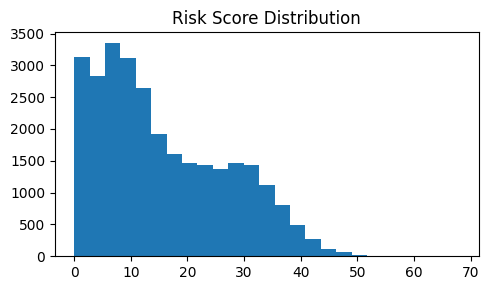

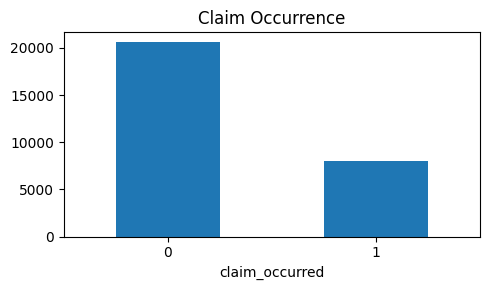

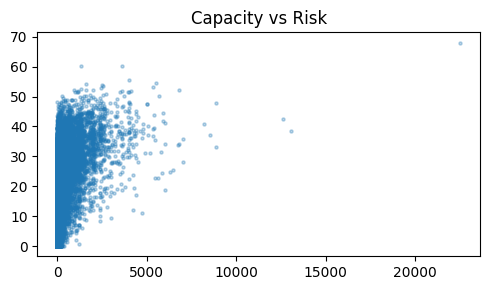

In [9]:
# Cell 5 - EDA (core distributions)

import matplotlib.pyplot as plt

# ----------------------------
# 1. Risk Score Distribution
# ----------------------------
plt.figure(figsize=(5, 3))
plt.hist(risk_df["risk_score"], bins=25)
plt.title("Risk Score Distribution")
plt.tight_layout()
plt.show()

# ----------------------------
# 2. Claim Occurrence Distribution
# ----------------------------
plt.figure(figsize=(5, 3))
risk_df["claim_occurred"].value_counts().plot(kind="bar")
plt.title("Claim Occurrence")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------
# 3. Capacity vs Risk
# ----------------------------
plt.figure(figsize=(5, 3))
plt.scatter(
    risk_df["capacity_mw"],
    risk_df["risk_score"],
    alpha=0.3,
    s=5
)
plt.title("Capacity vs Risk")
plt.tight_layout()
plt.show()

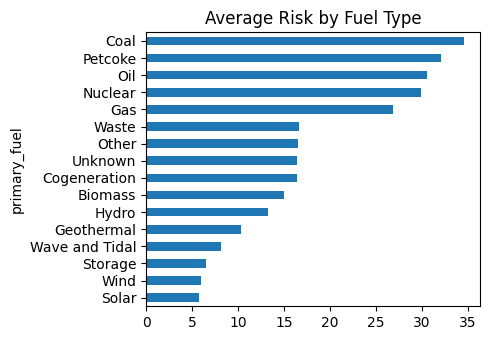

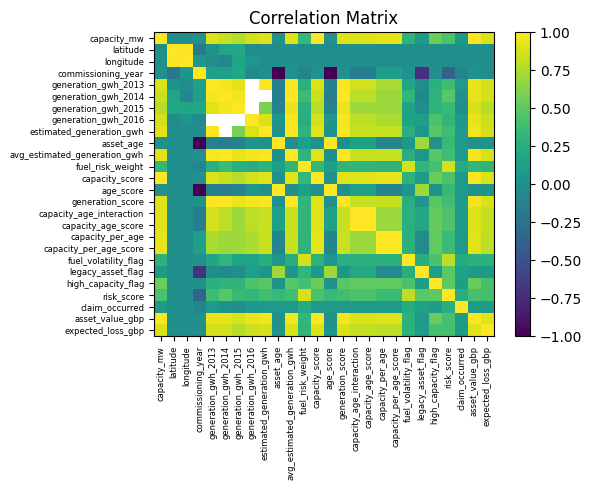

In [10]:
# Cell 6 - EDA (segmentation + correlation)

import matplotlib.pyplot as plt

# ----------------------------
# 4. Risk Score by Fuel Type
# ----------------------------
if "primary_fuel" in risk_df.columns:
    plt.figure(figsize=(5, 3.5))
    risk_df.groupby("primary_fuel")["risk_score"].mean().sort_values().plot(kind="barh")
    plt.title("Average Risk by Fuel Type")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 5. Correlation Heatmap
# ----------------------------
numeric_cols = risk_df.select_dtypes(include=["number"]).columns
corr = risk_df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, aspect="auto")
plt.title("Correlation Matrix")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)

plt.colorbar()
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 - UPGRADE: create a more realistic synthetic insurance-style target
# Reproducibility fix included: seed is set at the top of the cell

import numpy as np # Import numpy
import pandas as pd # Import pandas for min_max_scale and other dataframe ops

# This version improves the project by:
# 1. Creating richer engineered features
# 2. Building a less deterministic target
# 3. Adding controlled randomness ("noise")
# 4. Producing both:
#    - risk_score (regression target)
#    - claim_occurred (classification target)
# 5. Creating expected_loss_gbp for financial storytelling

np.random.seed(42)

risk_df = model_df.copy()

# ----------------------------
# Basic numeric cleanup
# ----------------------------
if "capacity_mw" in risk_df.columns:
    risk_df["capacity_mw"] = pd.to_numeric(risk_df["capacity_mw"], errors="coerce")
    risk_df["capacity_mw"] = risk_df["capacity_mw"].fillna(risk_df["capacity_mw"].median())
else:
    risk_df["capacity_mw"] = 0

if "asset_age" in risk_df.columns:
    risk_df["asset_age"] = pd.to_numeric(risk_df["asset_age"], errors="coerce")
    risk_df["asset_age"] = risk_df["asset_age"].fillna(risk_df["asset_age"].median())
else:
    risk_df["asset_age"] = 20

if "avg_estimated_generation_gwh" in risk_df.columns:
    risk_df["avg_estimated_generation_gwh"] = pd.to_numeric(
        risk_df["avg_estimated_generation_gwh"], errors="coerce"
    )
else:
    risk_df["avg_estimated_generation_gwh"] = np.nan

# If generation is mostly missing, create a sensible proxy from capacity
if risk_df["avg_estimated_generation_gwh"].isna().mean() > 0.5:
    generation_multiplier = np.random.uniform(2.5, 5.5, len(risk_df))
    risk_df["avg_estimated_generation_gwh"] = risk_df["capacity_mw"] * generation_multiplier
else:
    risk_df["avg_estimated_generation_gwh"] = risk_df["avg_estimated_generation_gwh"].fillna(
        risk_df["avg_estimated_generation_gwh"].median()
    )

# ----------------------------
# Clean text fields
# ----------------------------
for col in ["primary_fuel", "country_long", "owner", "source"]:
    if col in risk_df.columns:
        risk_df[col] = risk_df[col].astype(str).str.strip()
        risk_df[col] = risk_df[col].replace(["", "nan", "None"], "Unknown")

# ----------------------------
# Fuel-based risk weighting
# ----------------------------
fuel_risk_map = {
    "Coal": 0.92,
    "Oil": 0.88,
    "Petcoke": 0.86,
    "Gas": 0.68,
    "Biomass": 0.58,
    "Waste": 0.62,
    "Cogeneration": 0.52,
    "Hydro": 0.34,
    "Nuclear": 0.78,
    "Solar": 0.19,
    "Wind": 0.17,
    "Geothermal": 0.28,
    "Wave and Tidal": 0.24,
    "Storage": 0.22,
    "Other": 0.50
}

risk_df["fuel_risk_weight"] = (
    risk_df["primary_fuel"].map(fuel_risk_map).fillna(0.50)
    if "primary_fuel" in risk_df.columns
    else 0.50
)

# ----------------------------
# Helper scaling function
# ----------------------------
def min_max_scale(series):
    series = pd.to_numeric(series, errors="coerce")
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
        return pd.Series(0.5, index=series.index)
    return (series - min_val) / (max_val - min_val)

# ----------------------------
# Core scaled features
# ----------------------------
risk_df["capacity_score"] = min_max_scale(risk_df["capacity_mw"])
risk_df["age_score"] = min_max_scale(risk_df["asset_age"])
risk_df["generation_score"] = min_max_scale(risk_df["avg_estimated_generation_gwh"])

# ----------------------------
# Elite engineered features
# ----------------------------
risk_df["capacity_age_interaction"] = risk_df["capacity_mw"] * (risk_df["asset_age"] + 1)
risk_df["capacity_age_score"] = min_max_scale(risk_df["capacity_age_interaction"])

risk_df["capacity_per_age"] = risk_df["capacity_mw"] / (risk_df["asset_age"] + 1)
risk_df["capacity_per_age_score"] = min_max_scale(risk_df["capacity_per_age"])

high_volatility_fuels = ["Coal", "Oil", "Petcoke", "Gas"]
risk_df["fuel_volatility_flag"] = risk_df["primary_fuel"].isin(high_volatility_fuels).astype(int)

risk_df["legacy_asset_flag"] = (risk_df["asset_age"] >= risk_df["asset_age"].quantile(0.75)).astype(int)
risk_df["high_capacity_flag"] = (risk_df["capacity_mw"] >= risk_df["capacity_mw"].quantile(0.75)).astype(int)

# ----------------------------
# More realistic synthetic base risk
# ----------------------------
base_risk = (
    0.22 * risk_df["fuel_risk_weight"] +
    0.18 * risk_df["capacity_score"] +
    0.14 * risk_df["age_score"] +
    0.10 * risk_df["generation_score"] +
    0.16 * risk_df["capacity_age_score"] +
    0.08 * risk_df["capacity_per_age_score"] +
    0.06 * risk_df["fuel_volatility_flag"] +
    0.03 * risk_df["legacy_asset_flag"] +
    0.03 * risk_df["high_capacity_flag"]
)

noise = np.random.normal(loc=0, scale=0.045, size=len(risk_df))

risk_df["risk_score"] = (base_risk + noise) * 100
risk_df["risk_score"] = risk_df["risk_score"].clip(0, 100).round(2)

# ----------------------------
# Risk bands
# ----------------------------
risk_df["risk_band"] = pd.cut(
    risk_df["risk_score"],
    bins=[0, 35, 65, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

# ----------------------------
# Classification target for insurance-style modelling
# ----------------------------
claim_probability = (
    0.15 +
    (risk_df["risk_score"] / 100) * 0.55 +
    0.10 * risk_df["fuel_volatility_flag"] +
    0.05 * risk_df["legacy_asset_flag"]
).clip(0.05, 0.95)

random_draw = np.random.rand(len(risk_df))
risk_df["claim_occurred"] = (random_draw < claim_probability).astype(int)

# ----------------------------
# Financial exposure / expected loss
# ----------------------------
risk_df["asset_value_gbp"] = (
    500_000 +
    (risk_df["capacity_mw"] * 7_500) +
    (risk_df["avg_estimated_generation_gwh"] * 900)
).round(2)

severity_factor = np.random.uniform(0.015, 0.06, len(risk_df))
risk_df["expected_loss_gbp"] = (
    risk_df["asset_value_gbp"] *
    (risk_df["risk_score"] / 100) *
    severity_factor
).round(2)

print("Elite risk modelling dataset shape:", risk_df.shape)

print("\nRisk score summary:")
display(risk_df["risk_score"].describe())

print("\nRisk band counts:")
display(risk_df["risk_band"].value_counts())

print("\nClaim occurrence distribution:")
display(risk_df["claim_occurred"].value_counts(normalize=True).rename("proportion"))

print("\nPreview:")
display(risk_df.head())

Elite risk modelling dataset shape: (28664, 37)

Risk score summary:


,risk_score
count,28664.000000
mean,15.694106
std,11.447521
min,0.000000
25%,6.400000
50%,12.800000
75%,24.530000
max,68.070000



Risk band counts:


,count
risk_band,
Low Risk,26727
Medium Risk,1936
High Risk,1



Claim occurrence distribution:


,proportion
claim_occurred,
0,0.719718
1,0.280282



Preview:


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,fuel2,fuel3,fuel4,commissioning_year,owner,source,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh,asset_age,avg_estimated_generation_gwh,fuel_risk_weight,capacity_score,age_score,generation_score,capacity_age_interaction,capacity_age_score,capacity_per_age,capacity_per_age_score,fuel_volatility_flag,legacy_asset_flag,high_capacity_flag,risk_score,risk_band,claim_occurred,asset_value_gbp,expected_loss_gbp
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,NaN,Unknown,GEODB,NaN,NaN,NaN,NaN,NaN,22.0,49.53002,0.34,0.001422,0.114754,0.001216,759.00,0.001387,1.434783,0.001522,0,0,0,11.39,Low Risk,0,792077.02,3839.59
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,NaN,Unknown,GEODB,NaN,NaN,NaN,NaN,NaN,22.0,49.53002,0.34,0.002889,0.114754,0.001216,1518.00,0.002793,2.869565,0.003052,0,0,0,8.60,Low Risk,1,1039577.02,3600.52
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,NaN,Unknown,GEODB,NaN,NaN,NaN,NaN,NaN,22.0,49.53002,0.34,0.004400,0.114754,0.001216,2300.00,0.004241,4.347826,0.004629,0,0,1,15.20,Low Risk,0,1294577.02,9514.90
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,NaN,Unknown,GEODB,NaN,NaN,NaN,NaN,NaN,22.0,49.53002,0.34,0.000469,0.114754,0.001216,265.65,0.000473,0.502174,0.000527,0,0,0,15.97,Low Risk,0,631202.02,1693.41
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,NaN,Unknown,GEODB,NaN,NaN,NaN,NaN,NaN,22.0,49.53002,0.68,0.001822,0.114754,0.001216,966.00,0.001770,1.826087,0.001939,1,0,0,21.60,Low Risk,1,859577.02,10701.41


In [11]:
# Cell 8 - final modelling dataset (clean + reproducible + CV-ready)

# Create modelling copy
ml_df = risk_df.copy()

# ----------------------------
# Define feature columns (strong + interpretable)
# ----------------------------
feature_columns = [
    "capacity_mw",
    "latitude",
    "longitude",
    "asset_age",
    "avg_estimated_generation_gwh",
    "fuel_risk_weight",
    "capacity_age_interaction",
    "capacity_per_age",
    "fuel_volatility_flag",
    "legacy_asset_flag",
    "high_capacity_flag",
    "primary_fuel",
    "country_long"
]

feature_columns = [col for col in feature_columns if col in ml_df.columns]

# ----------------------------
# Targets
# ----------------------------
regression_target = "risk_score"
classification_target = "claim_occurred"
financial_target = "expected_loss_gbp"

# ----------------------------
# ID columns (for export later)
# ----------------------------
id_columns = [
    col for col in [
        "name",
        "gppd_idnr",
        "country",
        "country_long",
        "owner",
        "source"
    ] if col in ml_df.columns
]

# ----------------------------
# Build dataset
# ----------------------------
keep_columns = (
    id_columns +
    feature_columns +
    [col for col in [regression_target, classification_target, financial_target, "risk_band", "asset_value_gbp"] if col in ml_df.columns]
)

# Ensure unique columns to prevent 'DataFrame' object has no attribute 'str' error
keep_columns = list(np.unique(keep_columns))
final_ml_df = ml_df[keep_columns].copy()

# ----------------------------
# Drop missing targets
# ----------------------------
final_ml_df = final_ml_df.dropna(subset=[regression_target, classification_target])

# ----------------------------
# Clean categorical columns
# ----------------------------
categorical_cols = final_ml_df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    final_ml_df[col] = final_ml_df[col].astype(str).str.strip()
    final_ml_df[col] = final_ml_df[col].replace(["", "nan", "None"], "Unknown")

# ----------------------------
# Fill numeric nulls
# ----------------------------
numeric_cols = final_ml_df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    final_ml_df[col] = final_ml_df[col].fillna(final_ml_df[col].median())

# Ensure classification is int
final_ml_df[classification_target] = final_ml_df[classification_target].astype(int)


print("Final ML dataset shape:", final_ml_df.shape)

print("\nFeature columns:")
print(feature_columns)

print("\nTarget summary:")
print(f"{regression_target} mean:", final_ml_df[regression_target].mean().round(2))
print(f"{classification_target} rate:", final_ml_df[classification_target].mean().round(3))

print("\nMissing values (post-clean):")
display(final_ml_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nRisk band distribution:")
display(final_ml_df["risk_band"].value_counts())

print("\nClassification balance:")
display(final_ml_df[classification_target].value_counts(normalize=True).rename("proportion"))

print("\nPreview:")
display(final_ml_df.head())

Final ML dataset shape: (28664, 23)

Feature columns:
['capacity_mw', 'latitude', 'longitude', 'asset_age', 'avg_estimated_generation_gwh', 'fuel_risk_weight', 'capacity_age_interaction', 'capacity_per_age', 'fuel_volatility_flag', 'legacy_asset_flag', 'high_capacity_flag', 'primary_fuel', 'country_long']

Target summary:
risk_score mean: 15.69
claim_occurred rate: 0.28

Missing values (post-clean):


,0
asset_age,0
asset_value_gbp,0
avg_estimated_generation_gwh,0
capacity_age_interaction,0
capacity_mw,0
capacity_per_age,0
claim_occurred,0
country,0
country_long,0
expected_loss_gbp,0



Risk band distribution:


,count
risk_band,
Low Risk,26727
Medium Risk,1936
High Risk,1



Classification balance:


,proportion
claim_occurred,
0,0.719718
1,0.280282



Preview:


,asset_age,asset_value_gbp,avg_estimated_generation_gwh,capacity_age_interaction,capacity_mw,capacity_per_age,claim_occurred,country,country_long,expected_loss_gbp,fuel_risk_weight,fuel_volatility_flag,gppd_idnr,high_capacity_flag,latitude,legacy_asset_flag,longitude,name,owner,primary_fuel,risk_band,risk_score,source
0,22.0,792077.02,49.53002,759.00,33.00,1.434783,0,AFG,Afghanistan,3839.59,0.34,0,GEODB0040538,0,32.3220,0,65.1190,Kajaki Hydroelectric Power Plant Afghanistan,Unknown,Hydro,Low Risk,11.39,GEODB
1,22.0,1039577.02,49.53002,1518.00,66.00,2.869565,1,AFG,Afghanistan,3600.52,0.34,0,GEODB0040541,0,34.5560,0,69.4787,Mahipar Hydroelectric Power Plant Afghanistan,Unknown,Hydro,Low Risk,8.60,GEODB
2,22.0,1294577.02,49.53002,2300.00,100.00,4.347826,0,AFG,Afghanistan,9514.90,0.34,0,GEODB0040534,1,34.6410,0,69.7170,Naghlu Dam Hydroelectric Power Plant Afghanistan,Unknown,Hydro,Low Risk,15.20,GEODB
3,22.0,631202.02,49.53002,265.65,11.55,0.502174,0,AFG,Afghanistan,1693.41,0.34,0,GEODB0040536,0,34.4847,0,70.3633,Nangarhar (Darunta) Hydroelectric Power Plant ...,Unknown,Hydro,Low Risk,15.97,GEODB
4,22.0,859577.02,49.53002,966.00,42.00,1.826087,1,AFG,Afghanistan,10701.41,0.68,1,GEODB0040540,0,34.5638,0,69.1134,Northwest Kabul Power Plant Afghanistan,Unknown,Gas,Low Risk,21.60,GEODB


In [12]:
# Cell 9 - One-hot encoding, train/test split, and CV-ready datasets

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

# ----------------------------
# Separate features and targets
# ----------------------------
X = final_ml_df[feature_columns].copy()
y_reg = final_ml_df[regression_target].copy()
y_clf = final_ml_df[classification_target].copy()

# ----------------------------
# One-hot encode categorical features
# ----------------------------
X_encoded = pd.get_dummies(X, drop_first=True)

# ----------------------------
# Train/test split for regression
# ----------------------------
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_encoded,
    y_reg,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Train/test split for classification
# Stratify preserves class balance
# ----------------------------
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# ----------------------------
# Cross-validation objects
# ----------------------------
reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("X shape before encoding:", X.shape)
print("X shape after encoding:", X_encoded.shape)

print("\nRegression training set shape:", X_train_reg.shape)
print("Regression test set shape:", X_test_reg.shape)

print("\nClassification training set shape:", X_train_clf.shape)
print("Classification test set shape:", X_test_clf.shape)

print("\nEncoded feature sample:")
display(pd.DataFrame({"feature": X_encoded.columns}).head(20))

print("\nClassification target balance (full dataset):")
display(y_clf.value_counts(normalize=True).rename("proportion"))

print("\nCross-validation setup:")
print("Regression CV: KFold(n_splits=5, shuffle=True, random_state=42)")
print("Classification CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")

X shape before encoding: (28664, 13)
X shape after encoding: (28664, 189)

Regression training set shape: (22931, 189)
Regression test set shape: (5733, 189)

Classification training set shape: (22931, 189)
Classification test set shape: (5733, 189)

Encoded feature sample:


,feature
0,capacity_mw
1,latitude
2,longitude
3,asset_age
4,avg_estimated_generation_gwh
5,fuel_risk_weight
6,capacity_age_interaction
7,capacity_per_age
8,fuel_volatility_flag
9,legacy_asset_flag



Classification target balance (full dataset):


,proportion
claim_occurred,
0,0.719718
1,0.280282



Cross-validation setup:
Regression CV: KFold(n_splits=5, shuffle=True, random_state=42)
Classification CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [13]:
# Cell 10 - Train tuned regression + classification models with better imbalance handling

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

# ============================================================
# RUN MODE SETTINGS
# "fast"  = quicker development runs
# "final" = full-quality run for portfolio/export
# ============================================================
RUN_MODE = "final"   # options: "fast" or "final"

if RUN_MODE == "fast":
    rf_n_estimators = 120
    gb_n_estimators = 120
    cv_folds_reg = 3
    cv_folds_clf = 3
elif RUN_MODE == "final":
    rf_n_estimators = 300
    gb_n_estimators = 250
    cv_folds_reg = 5
    cv_folds_clf = 5
else:
    raise ValueError("RUN_MODE must be either 'fast' or 'final'")

print(f"Run mode: {RUN_MODE}")
print(f"Random Forest estimators: {rf_n_estimators}")
print(f"Gradient Boosting estimators: {gb_n_estimators}")
print(f"Regression CV folds: {cv_folds_reg}")
print(f"Classification CV folds: {cv_folds_clf}")

# ----------------------------
# REGRESSION MODELS
# ----------------------------
rf_reg_model = RandomForestRegressor(
    n_estimators=rf_n_estimators,
    max_depth=14,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gb_reg_model = GradientBoostingRegressor(
    n_estimators=gb_n_estimators,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train regression models
rf_reg_model.fit(X_train_reg, y_train_reg)
gb_reg_model.fit(X_train_reg, y_train_reg)

# Predict regression
rf_reg_preds = rf_reg_model.predict(X_test_reg)
gb_reg_preds = gb_reg_model.predict(X_test_reg)

def evaluate_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} - Regression Performance")
    print("-" * 45)
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

evaluate_regression(y_test_reg, rf_reg_preds, "Random Forest Regressor")
evaluate_regression(y_test_reg, gb_reg_preds, "Gradient Boosting Regressor")

# ----------------------------
# REGRESSION CROSS-VALIDATION
# ----------------------------
rf_reg_cv_r2 = cross_val_score(
    rf_reg_model,
    X_encoded,
    y_reg,
    cv=cv_folds_reg,
    scoring="r2",
    n_jobs=-1
)

gb_reg_cv_r2 = cross_val_score(
    gb_reg_model,
    X_encoded,
    y_reg,
    cv=cv_folds_reg,
    scoring="r2",
    n_jobs=-1
)

print("\nRegression Cross-Validation (R²):")
print(f"Random Forest CV R²: {rf_reg_cv_r2.mean():.4f} ± {rf_reg_cv_r2.std():.4f}")
print(f"Gradient Boosting CV R²: {gb_reg_cv_r2.mean():.4f} ± {gb_reg_cv_r2.std():.4f}")

# ----------------------------
# CLASSIFICATION MODELS
# Key improvement: class imbalance handling
# ----------------------------

# Random Forest can use built-in class balancing
rf_clf_model = RandomForestClassifier(
    n_estimators=rf_n_estimators,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting doesn't support class_weight directly,
# so we create sample weights for training
gb_clf_model = GradientBoostingClassifier(
    n_estimators=gb_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

clf_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_clf
)

# Train classification models
rf_clf_model.fit(X_train_clf, y_train_clf)
gb_clf_model.fit(X_train_clf, y_train_clf, sample_weight=clf_sample_weights)

# Predict classification
rf_clf_preds = rf_clf_model.predict(X_test_clf)
gb_clf_preds = gb_clf_model.predict(X_test_clf)

rf_clf_probs = rf_clf_model.predict_proba(X_test_clf)[:, 1]
gb_clf_probs = gb_clf_model.predict_proba(X_test_clf)[:, 1]

def evaluate_classification(y_true, y_pred, y_prob, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name} - Classification Performance")
    print("-" * 45)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

evaluate_classification(y_test_clf, rf_clf_preds, rf_clf_probs, "Random Forest Classifier")
evaluate_classification(y_test_clf, gb_clf_preds, gb_clf_probs, "Gradient Boosting Classifier")

# ----------------------------
# CLASSIFICATION CROSS-VALIDATION
# ----------------------------
rf_clf_cv_auc = cross_val_score(
    rf_clf_model,
    X_encoded,
    y_clf,
    cv=cv_folds_clf,
    scoring="roc_auc",
    n_jobs=-1
)

gb_clf_cv_auc = cross_val_score(
    gb_clf_model,
    X_encoded,
    y_clf,
    cv=cv_folds_clf,
    scoring="roc_auc",
    n_jobs=-1
)

print("\nClassification Cross-Validation (ROC AUC):")
print(f"Random Forest CV AUC: {rf_clf_cv_auc.mean():.4f} ± {rf_clf_cv_auc.std():.4f}")
print(f"Gradient Boosting CV AUC: {gb_clf_cv_auc.mean():.4f} ± {gb_clf_cv_auc.std():.4f}")

Run mode: final
Random Forest estimators: 300
Gradient Boosting estimators: 250
Regression CV folds: 5
Classification CV folds: 5

Random Forest Regressor - Regression Performance
---------------------------------------------
MAE:  3.5425
RMSE: 4.4011
R²:   0.8536

Gradient Boosting Regressor - Regression Performance
---------------------------------------------
MAE:  3.4979
RMSE: 4.3378
R²:   0.8577

Regression Cross-Validation (R²):
Random Forest CV R²: 0.8432 ± 0.0175
Gradient Boosting CV R²: 0.8489 ± 0.0173

Random Forest Classifier - Classification Performance
---------------------------------------------
Accuracy:  0.6571
Precision: 0.4157
Recall:    0.5507
F1 Score:  0.4738
ROC AUC:   0.6488

Gradient Boosting Classifier - Classification Performance
---------------------------------------------
Accuracy:  0.6543
Precision: 0.4138
Recall:    0.5600
F1 Score:  0.4759
ROC AUC:   0.6472

Classification Cross-Validation (ROC AUC):
Random Forest CV AUC: 0.6132 ± 0.0344
Gradient Boosti

In [14]:
# Cell 11 - Model comparison and robust selection logic

# ----------------------------
# Regression model comparison
# ----------------------------
regression_results = pd.DataFrame({
    "Model": ["Random Forest Regressor", "Gradient Boosting Regressor"],
    "MAE": [
        mean_absolute_error(y_test_reg, rf_reg_preds),
        mean_absolute_error(y_test_reg, gb_reg_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, rf_reg_preds)),
        np.sqrt(mean_squared_error(y_test_reg, gb_reg_preds))
    ],
    "R2": [
        r2_score(y_test_reg, rf_reg_preds),
        r2_score(y_test_reg, gb_reg_preds)
    ],
    "CV_R2_Mean": [
        rf_reg_cv_r2.mean(),
        gb_reg_cv_r2.mean()
    ],
    "CV_R2_Std": [
        rf_reg_cv_r2.std(),
        gb_reg_cv_r2.std()
    ]
}).sort_values(by=["CV_R2_Mean", "R2"], ascending=False)

print("Regression Model Comparison:")
display(regression_results)

best_reg_model_name = regression_results.iloc[0]["Model"]

if best_reg_model_name == "Random Forest Regressor":
    best_reg_model = rf_reg_model
    best_reg_preds = rf_reg_preds
else:
    best_reg_model = gb_reg_model
    best_reg_preds = gb_reg_preds

print(f"\nBest regression model selected: {best_reg_model_name}")

# ----------------------------
# Classification model comparison
# Key improvement: focus on ROC AUC + Recall + F1 (not accuracy)
# ----------------------------
classification_results = pd.DataFrame({
    "Model": ["Random Forest Classifier", "Gradient Boosting Classifier"],
    "Accuracy": [
        accuracy_score(y_test_clf, rf_clf_preds),
        accuracy_score(y_test_clf, gb_clf_preds)
    ],
    "Precision": [
        precision_score(y_test_clf, rf_clf_preds, zero_division=0),
        precision_score(y_test_clf, gb_clf_preds, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_clf, rf_clf_preds, zero_division=0),
        recall_score(y_test_clf, gb_clf_preds, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_clf, rf_clf_preds, zero_division=0),
        f1_score(y_test_clf, gb_clf_preds, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test_clf, rf_clf_probs),
        roc_auc_score(y_test_clf, gb_clf_probs)
    ],
    "CV_ROC_AUC_Mean": [
        rf_clf_cv_auc.mean(),
        gb_clf_cv_auc.mean()
    ],
    "CV_ROC_AUC_Std": [
        rf_clf_cv_auc.std(),
        gb_clf_cv_auc.std()
    ]
}).sort_values(by=["CV_ROC_AUC_Mean", "ROC_AUC"], ascending=False)

print("\nClassification Model Comparison:")
display(classification_results)

# ----------------------------
# Improved selection logic
# Prioritise:
# 1. ROC AUC (ranking ability)
# 2. Recall (finding events)
# 3. F1 (balance)
# ----------------------------

# Select best model by ROC AUC
best_clf_model_name = classification_results.iloc[0]["Model"]

if best_clf_model_name == "Random Forest Classifier":
    best_clf_model = rf_clf_model
    best_clf_preds = rf_clf_preds
    best_clf_probs = rf_clf_probs
else:
    best_clf_model = gb_clf_model
    best_clf_preds = gb_clf_preds
    best_clf_probs = gb_clf_probs

print(f"\nBest classification model selected (by ROC AUC): {best_clf_model_name}")

# ----------------------------
# Additional transparency
# ----------------------------
print("\n⚠️ Classification note:")
print("Model selection prioritises ROC AUC due to class imbalance.")
print("Recall and F1 should be reviewed alongside AUC for real-world use.")

Regression Model Comparison:


,Model,MAE,RMSE,R2,CV_R2_Mean,CV_R2_Std
1,Gradient Boosting Regressor,3.497898,4.337754,0.857737,0.848858,0.017323
0,Random Forest Regressor,3.542457,4.401055,0.853555,0.843216,0.017469



Best regression model selected: Gradient Boosting Regressor

Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Random Forest Classifier,0.657073,0.415688,0.550716,0.473769,0.648784,0.613202,0.034357
1,Gradient Boosting Classifier,0.654282,0.413793,0.560050,0.475939,0.647219,0.589845,0.054394



Best classification model selected (by ROC AUC): Random Forest Classifier

⚠️ Classification note:
Model selection prioritises ROC AUC due to class imbalance.
Recall and F1 should be reviewed alongside AUC for real-world use.


In [15]:
# Cell 12 - Generate full-dataset predictions with classifier-friendly outputs

# ----------------------------
# Recreate encoded features for FULL dataset
# ----------------------------
X_full = final_ml_df[feature_columns].copy()
X_full_encoded = pd.get_dummies(X_full, drop_first=True)

# Align columns with training structure
X_full_encoded = X_full_encoded.reindex(columns=X_train_reg.columns, fill_value=0)

# ----------------------------
# Regression predictions
# ----------------------------
final_ml_df["predicted_risk_score"] = best_reg_model.predict(X_full_encoded)
final_ml_df["predicted_risk_score"] = final_ml_df["predicted_risk_score"].clip(0, 100).round(2)

final_ml_df["predicted_risk_band"] = pd.cut(
    final_ml_df["predicted_risk_score"],
    bins=[0, 35, 65, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

# ----------------------------
# Classification predictions
# ----------------------------
final_ml_df["predicted_claim_probability"] = best_clf_model.predict_proba(X_full_encoded)[:, 1]
final_ml_df["predicted_claim_probability"] = final_ml_df["predicted_claim_probability"].round(4)

# Default classifier prediction at 0.50 threshold
final_ml_df["predicted_claim_occurred"] = (
    final_ml_df["predicted_claim_probability"] >= 0.50
).astype(int)

# Lower-threshold operational flag for risk screening
# This is useful when recall matters more than strict precision
screening_threshold = 0.35
final_ml_df["predicted_claim_flag_screening"] = (
    final_ml_df["predicted_claim_probability"] >= screening_threshold
).astype(int)

# Probability band for dashboard storytelling
final_ml_df["claim_probability_band"] = pd.cut(
    final_ml_df["predicted_claim_probability"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["Very Low", "Low", "Medium", "High"],
    include_lowest=True
)

# ----------------------------
# Predicted expected loss
# ----------------------------
if "asset_value_gbp" in final_ml_df.columns:
    # 8% assumed loss-given-event rate — illustrative proxy, not actuarial estimate
    final_ml_df["predicted_expected_loss_gbp"] = (
        final_ml_df["asset_value_gbp"] *
        (final_ml_df["predicted_risk_score"] / 100) *
        final_ml_df["predicted_claim_probability"] *
        0.08
    ).round(2)
else:
    final_ml_df["predicted_expected_loss_gbp"] = np.nan

# Optional business guardrail
final_ml_df["predicted_expected_loss_gbp"] = final_ml_df["predicted_expected_loss_gbp"].clip(lower=0)

print("Prediction dataset shape:", final_ml_df.shape)
print(f"\nScreening threshold used: {screening_threshold:.2f}")

preview_cols = [
    col for col in [
        "name",
        "gppd_idnr",
        "primary_fuel",
        "capacity_mw",
        "risk_score",
        "predicted_risk_score",
        "claim_occurred",
        "predicted_claim_probability",
        "predicted_claim_occurred",
        "predicted_claim_flag_screening",
        "claim_probability_band",
        "expected_loss_gbp",
        "predicted_expected_loss_gbp"
    ] if col in final_ml_df.columns
]

print("\nPreview of prediction outputs:")
display(final_ml_df[preview_cols].head())

Prediction dataset shape: (28664, 30)

Screening threshold used: 0.35

Preview of prediction outputs:


,name,gppd_idnr,primary_fuel,capacity_mw,risk_score,predicted_risk_score,claim_occurred,predicted_claim_probability,predicted_claim_occurred,predicted_claim_flag_screening,claim_probability_band,expected_loss_gbp,predicted_expected_loss_gbp
0,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,Hydro,33.00,11.39,9.11,0,0.3883,0,1,Low,3839.59,2241.52
1,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,Hydro,66.00,8.60,9.53,1,0.4066,0,1,Low,3600.52,3222.60
2,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,Hydro,100.00,15.20,12.32,0,0.4210,0,1,Low,9514.90,5371.69
3,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,Hydro,11.55,15.97,9.11,0,0.3801,0,1,Low,1693.41,1748.54
4,Northwest Kabul Power Plant Afghanistan,GEODB0040540,Gas,42.00,21.60,22.68,1,0.6164,1,1,Medium,10701.41,9613.48


In [16]:
# Cell 13 - Export datasets for Power BI + portfolio use (with screening outputs)

# ----------------------------
# Main export dataset
# ----------------------------
export_columns = [
    col for col in [
        "name",
        "gppd_idnr",
        "country",
        "country_long",
        "owner",
        "source",
        "primary_fuel",
        "capacity_mw",
        "latitude",
        "longitude",
        "asset_age",
        "avg_estimated_generation_gwh",
        "fuel_risk_weight",
        "fuel_volatility_flag",
        "legacy_asset_flag",
        "high_capacity_flag",
        "risk_score",
        "predicted_risk_score",
        "risk_band",
        "predicted_risk_band",
        "claim_occurred",
        "predicted_claim_probability",
        "predicted_claim_occurred",
        "predicted_claim_flag_screening",
        "claim_probability_band",
        "asset_value_gbp",
        "expected_loss_gbp",
        "predicted_expected_loss_gbp"
    ] if col in final_ml_df.columns
]

export_df = final_ml_df[export_columns].copy()

# Sort by highest predicted financial exposure
if "predicted_expected_loss_gbp" in export_df.columns:
    export_df = export_df.sort_values(by="predicted_expected_loss_gbp", ascending=False)

# ----------------------------
# Save main dataset
# ----------------------------
main_file = "energy_asset_risk_predictions.csv"
export_df.to_csv(main_file, index=False)

print(f"Saved main dataset: {main_file}")
print("Shape:", export_df.shape)

print("\nPreview:")
display(export_df.head())

# ----------------------------
# Fuel-level summary
# ----------------------------
summary_df = export_df.groupby("primary_fuel", dropna=False).agg(
    asset_count=("gppd_idnr", "count"),
    avg_actual_risk=("risk_score", "mean"),
    avg_predicted_risk=("predicted_risk_score", "mean"),
    actual_claim_rate=("claim_occurred", "mean"),
    avg_claim_probability=("predicted_claim_probability", "mean"),
    screening_flag_rate=("predicted_claim_flag_screening", "mean"),
    total_expected_loss=("predicted_expected_loss_gbp", "sum")
).reset_index()

summary_df = summary_df.sort_values(by="total_expected_loss", ascending=False)

summary_file = "energy_asset_risk_summary_by_fuel.csv"
summary_df.to_csv(summary_file, index=False)

print(f"\nSaved summary dataset: {summary_file}")
print("Shape:", summary_df.shape)

print("\nFuel summary preview:")
display(summary_df.head())

# ----------------------------
# Country-level summary
# ----------------------------
if "country_long" in export_df.columns:
    country_summary_df = export_df.groupby("country_long", dropna=False).agg(
        asset_count=("gppd_idnr", "count"),
        avg_predicted_risk=("predicted_risk_score", "mean"),
        avg_claim_probability=("predicted_claim_probability", "mean"),
        screening_flag_rate=("predicted_claim_flag_screening", "mean"),
        total_expected_loss=("predicted_expected_loss_gbp", "sum")
    ).reset_index().sort_values(by="total_expected_loss", ascending=False)

    country_file = "energy_asset_risk_summary_by_country.csv"
    country_summary_df.to_csv(country_file, index=False)

    print(f"\nSaved country summary dataset: {country_file}")
    print("Shape:", country_summary_df.shape)

    print("\nCountry summary preview:")
    display(country_summary_df.head())

Saved main dataset: energy_asset_risk_predictions.csv
Shape: (28664, 28)

Preview:


,name,gppd_idnr,country,country_long,owner,source,primary_fuel,capacity_mw,latitude,longitude,asset_age,avg_estimated_generation_gwh,fuel_risk_weight,fuel_volatility_flag,legacy_asset_flag,high_capacity_flag,risk_score,predicted_risk_score,risk_band,predicted_risk_band,claim_occurred,predicted_claim_probability,predicted_claim_occurred,predicted_claim_flag_screening,claim_probability_band,asset_value_gbp,expected_loss_gbp,predicted_expected_loss_gbp
7128,Three Gorges Dam,WRI1000452,CHN,China,Unknown,China Three Gorges Corporation,Hydro,22500.0,30.8235,111.0032,23.0,92268.763466,0.34,0,1,1,68.07,65.92,High Risk,High Risk,0,0.5570,1,1,Medium,2.522919e+08,6631011.77,7410809.78
7320,Xiluodu,WRI1000453,CHN,China,Unknown,Chinese National Committee on Large Dams,Hydro,12600.0,28.2600,103.6500,13.0,51670.507541,0.34,0,0,1,42.50,40.24,Medium Risk,Medium Risk,1,0.5731,1,1,Medium,1.415035e+08,3138794.75,2610630.56
4886,Baihetan Dam,WRI1070877,CHN,China,Unknown,Industry About,Hydro,13050.0,28.2606,103.6484,22.0,53515.882810,0.34,0,0,1,38.59,38.13,Medium Risk,Medium Risk,1,0.5828,1,1,Medium,1.465393e+08,1357917.11,2605136.19
17206,Taizhong Taichung,WRI1000364,TWN,Taiwan,Unknown,Bureau of Ministry Energy and Economic Affairs,Coal,5500.0,24.2131,120.4850,22.0,57964.915966,0.92,1,0,1,54.68,49.23,Medium Risk,Medium Risk,0,0.5069,1,1,Medium,9.391842e+07,2133109.47,1874963.91
15621,CHP-23,WRI1003692,RUS,Russia,Mosenergo (subsidiary of Gazprom),Mosenergo,Gas,5690.0,55.9160,37.6910,60.0,47140.489374,0.68,1,1,1,50.32,46.78,Medium Risk,Medium Risk,0,0.5342,1,1,Medium,8.560144e+07,2098170.65,1711335.51



Saved summary dataset: energy_asset_risk_summary_by_fuel.csv
Shape: (16, 8)

Fuel summary preview:


,primary_fuel,asset_count,avg_actual_risk,avg_predicted_risk,actual_claim_rate,avg_claim_probability,screening_flag_rate,total_expected_loss
1,Coal,2172,34.618697,34.548706,0.469613,0.669967,1.000000,4.704285e+08
3,Gas,3068,26.887666,26.859824,0.430574,0.643058,1.000000,2.227757e+08
7,Oil,2925,30.585791,30.489716,0.441368,0.645120,1.000000,1.066042e+08
5,Hydro,7034,13.245247,13.287994,0.237418,0.438840,0.966022,1.039785e+08
6,Nuclear,199,29.967990,30.262864,0.361809,0.564481,1.000000,7.669431e+07



Saved country summary dataset: energy_asset_risk_summary_by_country.csv
Shape: (164, 6)

Country summary preview:


,country_long,asset_count,avg_predicted_risk,avg_claim_probability,screening_flag_rate,total_expected_loss
155,United States of America,8119,18.530659,0.519548,0.970317,2.528846e+08
30,China,2901,16.559821,0.482692,0.978628,2.448429e+08
67,India,845,19.344391,0.516994,0.965680,5.553897e+07
75,Japan,325,17.227446,0.465992,0.640000,4.038564e+07
124,Russia,157,31.956752,0.626804,1.000000,3.691191e+07


In [17]:
# Cell 14 - Feature importance exports for regression + classification (with dashboard-ready groupings)

# ----------------------------
# Regression feature importance
# ----------------------------
reg_feature_importance = pd.DataFrame({
    "feature": X_train_reg.columns,
    "importance": best_reg_model.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

reg_feature_importance["importance_pct"] = (
    reg_feature_importance["importance"] / reg_feature_importance["importance"].sum()
) * 100
reg_feature_importance["model_type"] = "Regression"
reg_feature_importance["target"] = regression_target
reg_feature_importance["rank"] = reg_feature_importance.index + 1

# ----------------------------
# Classification feature importance
# ----------------------------
clf_feature_importance = pd.DataFrame({
    "feature": X_train_clf.columns,
    "importance": best_clf_model.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

clf_feature_importance["importance_pct"] = (
    clf_feature_importance["importance"] / clf_feature_importance["importance"].sum()
) * 100
clf_feature_importance["model_type"] = "Classification"
clf_feature_importance["target"] = classification_target
clf_feature_importance["rank"] = clf_feature_importance.index + 1

# ----------------------------
# Simple feature grouping for Power BI storytelling
# ----------------------------
def classify_feature_group(feature_name):
    feature_name = str(feature_name).lower()

    if "fuel" in feature_name:
        return "Fuel"
    elif "country" in feature_name or "latitude" in feature_name or "longitude" in feature_name:
        return "Geography"
    elif "age" in feature_name or "legacy" in feature_name:
        return "Asset Age"
    elif "capacity" in feature_name or "generation" in feature_name or "high_capacity" in feature_name:
        return "Asset Scale"
    else:
        return "Other"

reg_feature_importance["feature_group"] = reg_feature_importance["feature"].apply(classify_feature_group)
clf_feature_importance["feature_group"] = clf_feature_importance["feature"].apply(classify_feature_group)

# ----------------------------
# Export individual files
# ----------------------------
reg_feature_importance.to_csv("regression_feature_importance.csv", index=False)
clf_feature_importance.to_csv("classification_feature_importance.csv", index=False)

print("Saved: regression_feature_importance.csv")
print("Saved: classification_feature_importance.csv")

print("\nTop 15 Regression Feature Importances:")
display(reg_feature_importance.head(15))

print("\nTop 15 Classification Feature Importances:")
display(clf_feature_importance.head(15))

# ----------------------------
# Combined feature importance export
# ----------------------------
combined_feature_importance = pd.concat(
    [reg_feature_importance, clf_feature_importance],
    ignore_index=True
)

combined_feature_importance.to_csv("combined_feature_importance.csv", index=False)
print("\nSaved: combined_feature_importance.csv")

print("\nCombined feature importance preview:")
display(combined_feature_importance.head(15))

Saved: regression_feature_importance.csv
Saved: classification_feature_importance.csv

Top 15 Regression Feature Importances:


,feature,importance,importance_pct,model_type,target,rank,feature_group
0,fuel_risk_weight,0.884376,88.437607,Regression,risk_score,1,Fuel
1,asset_age,0.056694,5.669424,Regression,risk_score,2,Asset Age
2,capacity_age_interaction,0.028037,2.803747,Regression,risk_score,3,Asset Age
3,capacity_mw,0.006424,0.642424,Regression,risk_score,4,Asset Scale
4,fuel_volatility_flag,0.005872,0.587161,Regression,risk_score,5,Fuel
5,legacy_asset_flag,0.003372,0.337207,Regression,risk_score,6,Asset Age
6,avg_estimated_generation_gwh,0.003119,0.311883,Regression,risk_score,7,Asset Scale
7,primary_fuel_Coal,0.002108,0.210824,Regression,risk_score,8,Fuel
8,primary_fuel_Hydro,0.001999,0.199862,Regression,risk_score,9,Fuel
9,primary_fuel_Gas,0.001852,0.185171,Regression,risk_score,10,Fuel



Top 15 Classification Feature Importances:


,feature,importance,importance_pct,model_type,target,rank,feature_group
0,fuel_risk_weight,0.138982,13.898196,Classification,claim_occurred,1,Fuel
1,fuel_volatility_flag,0.128661,12.866070,Classification,claim_occurred,2,Fuel
2,capacity_age_interaction,0.078514,7.851427,Classification,claim_occurred,3,Asset Age
3,avg_estimated_generation_gwh,0.074543,7.454292,Classification,claim_occurred,4,Asset Scale
4,asset_age,0.073962,7.396163,Classification,claim_occurred,5,Asset Age
5,capacity_per_age,0.071541,7.154073,Classification,claim_occurred,6,Asset Age
6,capacity_mw,0.069173,6.917303,Classification,claim_occurred,7,Asset Scale
7,longitude,0.058349,5.834950,Classification,claim_occurred,8,Geography
8,latitude,0.057579,5.757936,Classification,claim_occurred,9,Geography
9,legacy_asset_flag,0.042999,4.299852,Classification,claim_occurred,10,Asset Age



Saved: combined_feature_importance.csv

Combined feature importance preview:


,feature,importance,importance_pct,model_type,target,rank,feature_group
0,fuel_risk_weight,0.884376,88.437607,Regression,risk_score,1,Fuel
1,asset_age,0.056694,5.669424,Regression,risk_score,2,Asset Age
2,capacity_age_interaction,0.028037,2.803747,Regression,risk_score,3,Asset Age
3,capacity_mw,0.006424,0.642424,Regression,risk_score,4,Asset Scale
4,fuel_volatility_flag,0.005872,0.587161,Regression,risk_score,5,Fuel
5,legacy_asset_flag,0.003372,0.337207,Regression,risk_score,6,Asset Age
6,avg_estimated_generation_gwh,0.003119,0.311883,Regression,risk_score,7,Asset Scale
7,primary_fuel_Coal,0.002108,0.210824,Regression,risk_score,8,Fuel
8,primary_fuel_Hydro,0.001999,0.199862,Regression,risk_score,9,Fuel
9,primary_fuel_Gas,0.001852,0.185171,Regression,risk_score,10,Fuel


In [18]:
# Cell 15 - Save models, export evaluation results, and final pipeline summary

import joblib

# ----------------------------
# Save best models
# ----------------------------
best_reg_model_file = "best_energy_risk_regression_model.pkl"
best_clf_model_file = "best_energy_risk_classification_model.pkl"

joblib.dump(best_reg_model, best_reg_model_file)
joblib.dump(best_clf_model, best_clf_model_file)

print(f"Saved: {best_reg_model_file}")
print(f"Saved: {best_clf_model_file}")

# ----------------------------
# Export evaluation results
# ----------------------------
regression_results.to_csv("regression_model_results.csv", index=False)
classification_results.to_csv("classification_model_results.csv", index=False)

print("Saved: regression_model_results.csv")
print("Saved: classification_model_results.csv")

# ----------------------------
# Final pipeline summary
# ----------------------------
print("\n=== MODEL SUMMARY ===")
print(f"Best regression model: {best_reg_model_name}")
print(f"Best classification model: {best_clf_model_name}")

print("\nKey outputs generated:")
print("- energy_asset_risk_predictions.csv")
print("- energy_asset_risk_summary_by_fuel.csv")
print("- energy_asset_risk_summary_by_country.csv")
print("- combined_feature_importance.csv")
print("- regression_model_results.csv")
print("- classification_model_results.csv")

print("\nModel files:")
print(f"- {best_reg_model_file}")
print(f"- {best_clf_model_file}")

print("\nNotes:")
print("- Classification model selection prioritised ROC AUC due to class imbalance")
print("- Screening flag included for operational risk identification")
print("- Expected loss uses an illustrative loss-given-event assumption (non-actuarial)")
print("- This is a simulation-based modelling workflow, not trained on real claims data")

print("\nPipeline complete.")

Saved: best_energy_risk_regression_model.pkl
Saved: best_energy_risk_classification_model.pkl
Saved: regression_model_results.csv
Saved: classification_model_results.csv

=== MODEL SUMMARY ===
Best regression model: Gradient Boosting Regressor
Best classification model: Random Forest Classifier

Key outputs generated:
- energy_asset_risk_predictions.csv
- energy_asset_risk_summary_by_fuel.csv
- energy_asset_risk_summary_by_country.csv
- combined_feature_importance.csv
- regression_model_results.csv
- classification_model_results.csv

Model files:
- best_energy_risk_regression_model.pkl
- best_energy_risk_classification_model.pkl

Notes:
- Classification model selection prioritised ROC AUC due to class imbalance
- Screening flag included for operational risk identification
- Expected loss uses an illustrative loss-given-event assumption (non-actuarial)
- This is a simulation-based modelling workflow, not trained on real claims data

Pipeline complete.
